# Data Preprocessing

In [1]:
import pandas as pd
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
# Load dataset
df = pd.read_csv("Sentiment_Data.csv", encoding='ISO-8859-1')

In [3]:
# Function for regex-based text cleaning
def clean_text(text):
    text = re.sub(r"http\S+|www\S+", "", text)         # Remove URLs
    text = re.sub(r"@\w+", "", text)                   # Remove mentions
    text = re.sub(r"#\w+", "", text)                   # Remove hashtags
    text = re.sub(r"[^\w\s.,!?]", "", text)            # Remove emojis/special chars
    text = re.sub(r"\s+", " ", text).strip()           # Remove extra whitespace
    return text

In [4]:
# Apply cleaning
df['Clean_Tweet'] = df['Tweet'].astype(str).apply(clean_text)

In [5]:
# Label encoding
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Sentiment'])

In [7]:
# Class distribution
print(df['Sentiment'].value_counts())

Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


In [8]:
# Train-test split (10% test set ensures ≥5000 samples)
train_df, test_df = train_test_split(df, test_size=0.1, stratify=df['Label'], random_state=42)

In [9]:
# Apply to the dataset
df['Clean_Tweet'] = df['Tweet'].astype(str).apply(clean_text)

In [10]:
# View result
print(df[['Tweet', 'Clean_Tweet']].head())

                                               Tweet  \
0  @_angelica_toy Happy Anniversary!!!....The Day...   
1  @McfarlaneGlenda Happy Anniversary!!!....The D...   
2  @thevivafrei @JustinTrudeau Happy Anniversary!...   
3  @NChartierET Happy Anniversary!!!....The Day t...   
4  @tabithapeters05 Happy Anniversary!!!....The D...   

                                         Clean_Tweet  
0  Happy Anniversary!!!....The Day the FreeDUMB D...  
1  Happy Anniversary!!!....The Day the FreeDUMB D...  
2  Happy Anniversary!!!....The Day the FreeDUMB D...  
3  Happy Anniversary!!!....The Day the FreeDUMB D...  
4  Happy Anniversary!!!....The Day the FreeDUMB D...  


In [11]:
# Install the emoji library
!pip install emoji

In [12]:
# Import the emoji library
import emoji

In [13]:
# Example slang/abbreviation dictionary
slang_dict = {
    "u": "you",
    "ur": "your",
    "lol": "laugh out loud",
    "omg": "oh my god",
    "idk": "I don't know",
    "btw": "by the way",
    "gr8": "great",
    "thx": "thanks",
    "pls": "please",
    "imo": "in my opinion"
}


In [14]:
# Function to expand slang/abbreviations
def expand_slang(text):
    words = text.split()
    return ' '.join([slang_dict.get(word.lower(), word) for word in words])


In [15]:
# Function to remove emojis
def remove_emojis(text):
    return emoji.replace_emoji(text, replace='')

In [16]:
# Combine everything: clean + expand + remove emojis
def clean_and_normalize(text):
    text = re.sub(r"http\S+|www\S+", "", text)         # Remove URLs
    text = re.sub(r"@\w+", "", text)                   # Remove mentions
    text = re.sub(r"#\w+", "", text)                   # Remove hashtags
    text = remove_emojis(text)                         # Remove emojis
    text = expand_slang(text)                          # Expand slang/abbreviations
    text = re.sub(r"[^\w\s.,!?]", "", text)            # Remove special characters
    text = re.sub(r"\s+", " ", text).strip()           # Normalize whitespace
    return text


In [17]:
# Apply to DataFrame
df = pd.read_csv("Sentiment_Data.csv", encoding='ISO-8859-1')
df['Clean_Tweet'] = df['Tweet'].astype(str).apply(clean_and_normalize)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [19]:
# Encode sentiment labels
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Sentiment'])

In [20]:
# Perform stratified split (e.g., 10% test set = 45,000+ samples in your case)
train_df, test_df = train_test_split(
    df,
    test_size=0.1,                # 10% test set
    stratify=df['Label'],         # Ensure class distribution remains balanced
    random_state=42
)

In [21]:
# Confirm split sizes
print(f"Train samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")  # Should be > 5000

Train samples: 406198
Test samples: 45134


In [22]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
# Label Encoding
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Sentiment'])


In [24]:
# View mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:")
print(label_mapping)


Label Mapping:
{'Mild_Neg': 0, 'Mild_Pos': 1, 'Neutral': 2, 'Strong_Neg': 3, 'Strong_Pos': 4}


In [25]:
# Class Balance (Value Counts)
print("\nClass Distribution:")
print(df['Sentiment'].value_counts())


Class Distribution:
Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


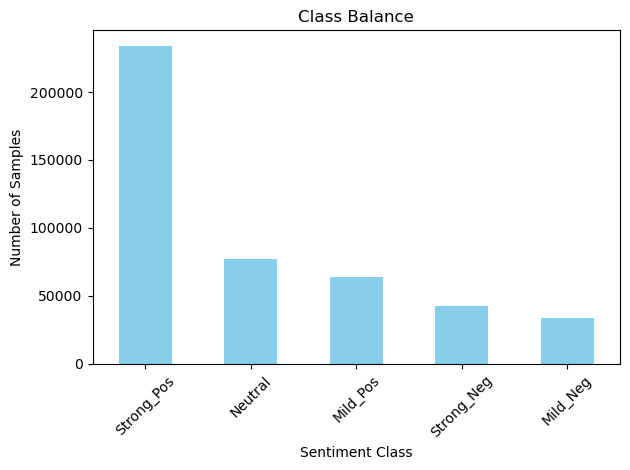

In [26]:
# Visualize class distribution
df['Sentiment'].value_counts().plot(kind='bar', title='Class Balance', color='skyblue')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# Save Cleaned Outputs
train_df.to_csv('train_data_preprocessed.csv', index=False)
test_df.to_csv('test_data_preprocessed.csv', index=False)

# Bidirectional GRU with Trainable Embedding Layer

In [30]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tqdm import tqdm

# Loading Preprocessed Data
df_train = pd.read_csv("train_data_preprocessed.csv")
df_test = pd.read_csv("test_data_preprocessed.csv")

# Ensure text data is clean
df_train['Clean_Tweet'] = df_train['Clean_Tweet'].astype(str).fillna("")
df_test['Clean_Tweet'] = df_test['Clean_Tweet'].astype(str).fillna("")

# Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df_train['Clean_Tweet'])
X_train_seq = tokenizer.texts_to_sequences(df_train['Clean_Tweet'])
X_test_seq = tokenizer.texts_to_sequences(df_test['Clean_Tweet'])

# Padding
MAX_LEN = 40
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

# Labels
y_train = df_train['Label'].values
y_test = df_test['Label'].values
VOCAB_SIZE = len(tokenizer.word_index) + 1
NUM_CLASSES = len(np.unique(y_train))

# Dataset
class TweetDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TweetDataset(X_train_pad, y_train)
test_dataset = TweetDataset(X_test_pad, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

# BiGRU Model
class BiGRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(BiGRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.gru(embedded)
        out = self.fc(output[:, -1, :])
        return out

# Training Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BiGRUModel(vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=64, output_dim=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training Loop
for epoch in range(5):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False)
    for X_batch, y_batch in loop:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == y_batch).sum().item()
        train_total += y_batch.size(0)
        loop.set_postfix(loss=loss.item(), batch_acc=(outputs.argmax(1) == y_batch).float().mean().item())

    train_acc = train_correct / train_total

    # Evaluation on test set
    model.eval()
    test_loss = 0
    test_correct = 0
    test_total = 0
    all_preds = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            preds = outputs.argmax(1)

            test_loss += loss.item()
            test_correct += (preds == y_batch).sum().item()
            test_total += y_batch.size(0)
            all_preds.extend(preds.cpu().numpy())

    test_acc = test_correct / test_total

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss = {train_loss:.4f}, Train Acc = {train_acc:.4f}")
    print(f"Test  Loss = {test_loss:.4f}, Test  Acc = {test_acc:.4f}\n")

# Final Prediction & Evaluation
print("Final Classification Report:")
print(classification_report(y_test, all_preds))

# Save the Model
MODEL_PATH = "bigru_model.pkl"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to '{MODEL_PATH}'")


Epoch 1:
Train Loss = 4552.8456, Train Acc = 0.7357
Test  Loss = 385.4222, Test  Acc = 0.8018



Epoch 2:
Train Loss = 3013.1846, Train Acc = 0.8283
Test  Loss = 335.8943, Test  Acc = 0.8299



Epoch 3:
Train Loss = 2508.5596, Train Acc = 0.8604
Test  Loss = 330.0975, Test  Acc = 0.8341



Epoch 4:
Train Loss = 2176.5679, Train Acc = 0.8813
Test  Loss = 329.1965, Test  Acc = 0.8389



Epoch 5:
Train Loss = 1903.4947, Train Acc = 0.8983
Test  Loss = 342.9259, Test  Acc = 0.8376

Final Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.63      0.62      3406
           1       0.70      0.70      0.70      6400
           2       0.80      0.77      0.78      7702
           3       0.81      0.76      0.79      4256
           4       0.93      0.94      0.93     23370

    accuracy                           0.84     45134
   macro avg       0.77      0.76      0.76     45134
weighted avg       0.84      0.84      0.84     45134

Model saved to 'bigru_model.pkl'


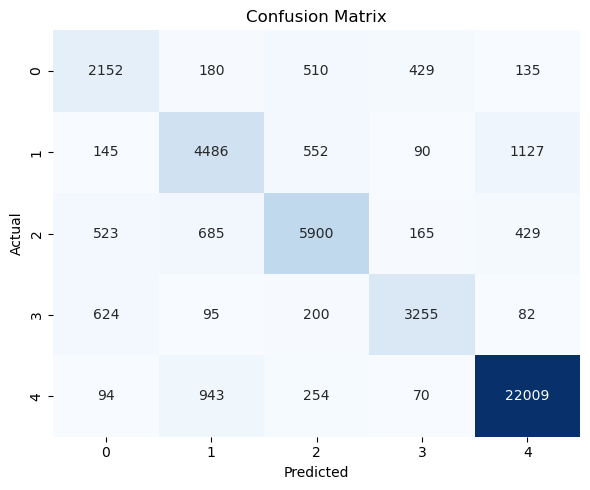

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [35]:
# Load the model
model = BiGRUModel(vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=64, output_dim=NUM_CLASSES).to(device)
model.load_state_dict(torch.load("bigru_model.pkl", map_location=device))
model.eval()

all_preds = []
true_labels = []
sample_texts = []

with torch.no_grad():
    for i, (X_batch, y_batch) in enumerate(test_loader):
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        true_labels.extend(y_batch.numpy())

# Some predictions with corresponding text and true label
print("Sample Predictions from Test Data:\n")
for i in range(10):  # show 10 examples
    original_text = df_test['Clean_Tweet'].iloc[i]
    predicted_label = all_preds[i]
    true_label = true_labels[i]
    print(f"Text: {original_text}\n → Predicted: {predicted_label} | True: {true_label}\n")

Sample Predictions from Test Data:

Text: The started sharing names of individuals and corporations, as well as their wallets, with financial institutions to freeze the accounts of some people involved with blockades and protests, federal ministers say.
 → Predicted: 4 | True: 1

Text: Whoa, Canada Police criminalize food, fuel donations to Freedom Convoy protest We are going to be interdicting anything that is supporting amp enabling the ongoing demonstrations amp occupations amp unlawful behavior in the city. Ottawa Police Chief
 → Predicted: 4 | True: 4

Text: Just closed my account at Im not huge but took 80k out! Fox Business Canadian Freedom Convoy TD Bank freezes accounts with 1.1M for trucker protest. via
 → Predicted: 4 | True: 4

Text: Those who donated money to the Freedom Convoy through GoFundMe needs to file a charge backdispute with your bank.
 → Predicted: 4 | True: 4

Text: You mean like a Real Canadians flag from the Freedom convoy...youre no Canadian...youre a globali

# Prompts used

- First: given the df_train.info() and df_test.info() prepare a BiGRU model with trainable embedding layer.
- Last: make sample predictions with test data